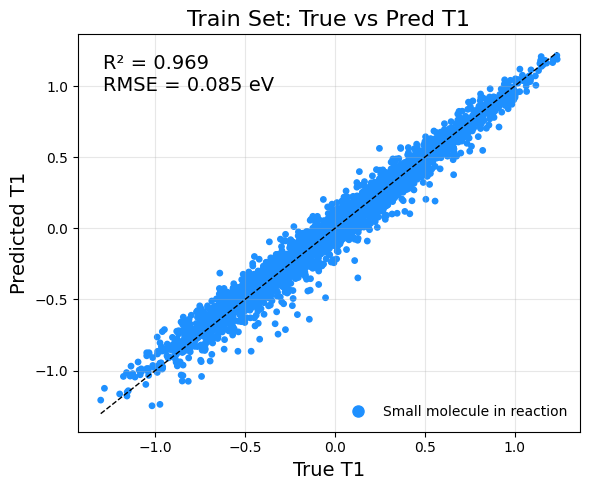

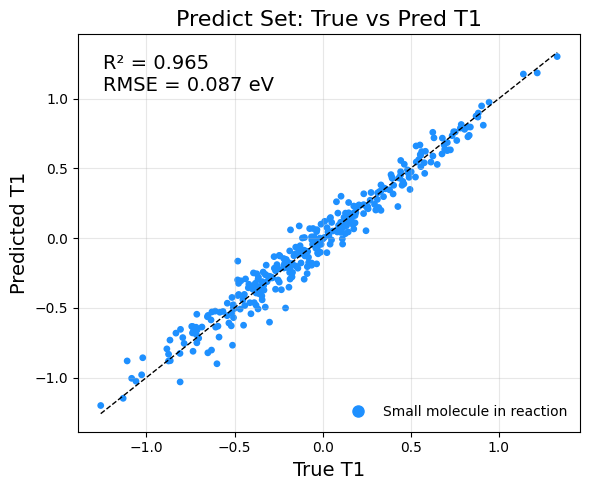

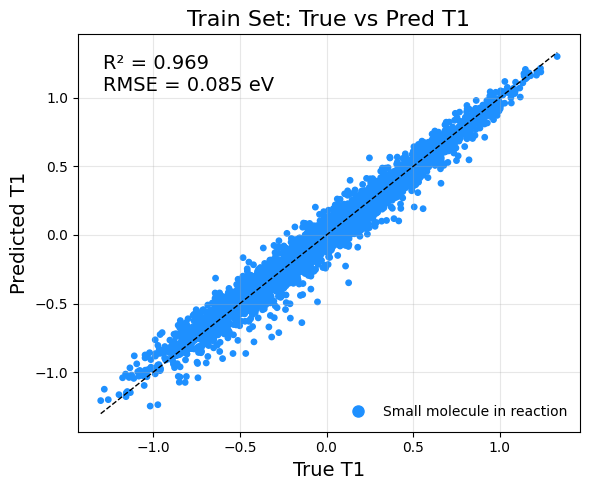

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

df = pd.read_csv("iter001/i001-predicted.csv")   # 修改为你的文件名

# 根据 task 设置颜色
df["color"] = df["task"].apply(lambda x: "dodgerblue" if ("HMB" not in x or "TMB" not in x) else "red")

def plot_dataset(df_sub, title):
    plt.figure(figsize=(6, 5))

    # 直接用 scatter 画全部点（颜色来自 df["color"]）
    plt.scatter(
        df_sub["true_T1"],
        df_sub["pred_T1"],
        c=df_sub["color"],
        s=15,
        edgecolors=df_sub["color"],
        # linewidth=0.2,
        alpha=1
    )

    plt.xlabel("True T1", fontsize=14)
    plt.ylabel("Predicted T1", fontsize=14)
    plt.title(title, fontsize=16)
    plt.grid(alpha=0.3)

    # y=x 基准线
    mn = min(df_sub["true_T1"].min(), df_sub["pred_T1"].min())
    mx = max(df_sub["true_T1"].max(), df_sub["pred_T1"].max())
    plt.plot([mn, mx], [mn, mx], "k--", lw=1)
    R2 = r2_score(df_sub["true_T1"], df_sub["pred_T1"])
    mse = mean_squared_error(df_sub["true_T1"], df_sub["pred_T1"])
    rmse = np.sqrt(mse)
    plt.text(
        0.05, 0.95,
        f"R² = {R2:.3f}\nRMSE = {rmse:.3f} eV",
        transform=plt.gca().transAxes,
        fontsize=14,
        verticalalignment='top'
    )
    # legend：人工构造两种颜色
    import matplotlib.lines as mlines
    blue_dot = mlines.Line2D([], [], color='dodgerblue', marker='o', linestyle='None',
                             markersize=8, label='Small molecule in reaction')
    # red_dot  = mlines.Line2D([], [], color='crimson', marker='o', linestyle='None',
    #                          markersize=8, label='Small Molecule')
    # plt.legend(handles=[blue_dot, red_dot], frameon=False)
    plt.legend(handles=[blue_dot], frameon=False)
    plt.tight_layout()
    plt.show()


# --- 分别画 train / predict ---
plot_dataset(df[df["dataset"] == "train"],   "Train Set: True vs Pred T1")
plot_dataset(df[df["dataset"] == "predict"], "Predict Set: True vs Pred T1")
plot_dataset(df,"Train Set: True vs Pred T1")